Upload your parking CSV file ...


Saving parking_birmingham (1).csv to parking_birmingham (1) (1).csv
Raw shape: (35717, 4)
  SystemCodeNumber  Capacity  Occupancy          LastUpdated
0      BHMBCCMKT01       577         61  2016-10-04 07:59:42
1      BHMBCCMKT01       577         64  2016-10-04 08:25:42
2      BHMBCCMKT01       577         80  2016-10-04 08:59:42
3      BHMBCCMKT01       577        107  2016-10-04 09:32:46
4      BHMBCCMKT01       577        150  2016-10-04 09:59:48
Removed 228 duplicate / invalid rows
Readings above capacity (capped): 373
Clean shape: (35437, 5) | car parks: 30
Date range: 2016-10-04 08:00:00 -> 2016-12-19 16:30:00


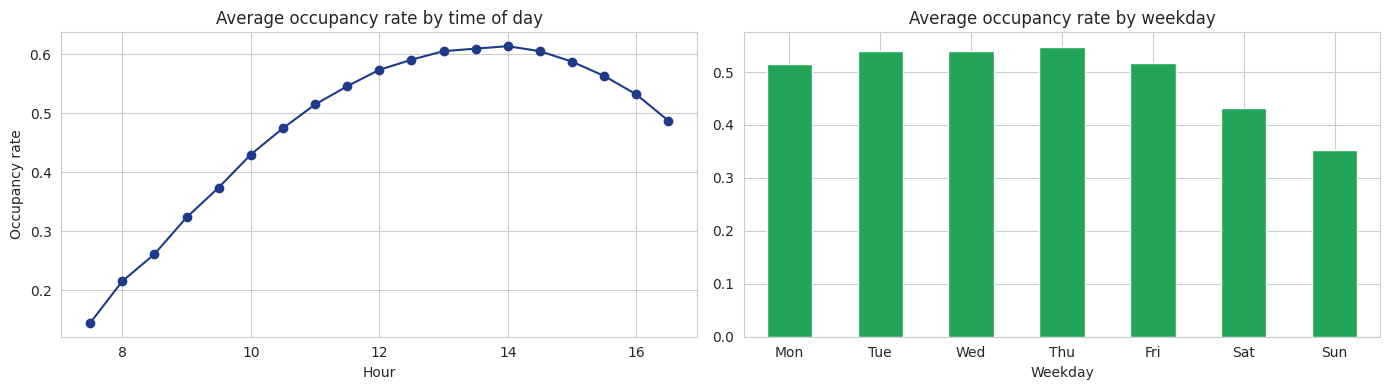

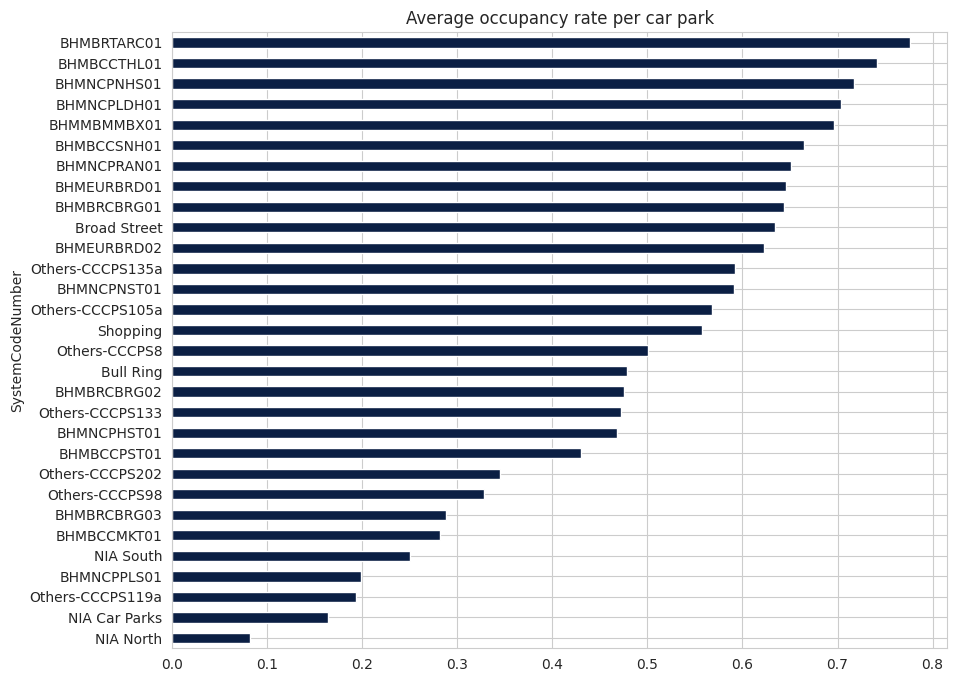

Dropped 3087 rows with no usable history
Features used: 17
                          count      mean       std      min      25%      50%       75%       max
Hour                    29317.0    12.269     2.578    7.500   10.000   12.500    14.500    16.500
Hour_sin                29317.0    -0.056     0.587   -0.924   -0.609   -0.131     0.500     0.924
Hour_cos                29317.0    -0.785     0.189   -1.000   -0.966   -0.866    -0.609    -0.383
Weekday                 29317.0     2.756     1.984    0.000    1.000    3.000     4.000     6.000
Wday_sin                29317.0     0.078     0.703   -0.975   -0.434    0.000     0.782     0.975
Wday_cos                29317.0     0.040     0.706   -0.901   -0.901   -0.223     0.623     1.000
IsWeekend               29317.0     0.245     0.430    0.000    0.000    0.000     0.000     1.000
Month                   29317.0    10.978     0.708   10.000   10.000   11.000    11.000    12.000
DayOfMonth              29317.0    15.666     8.21

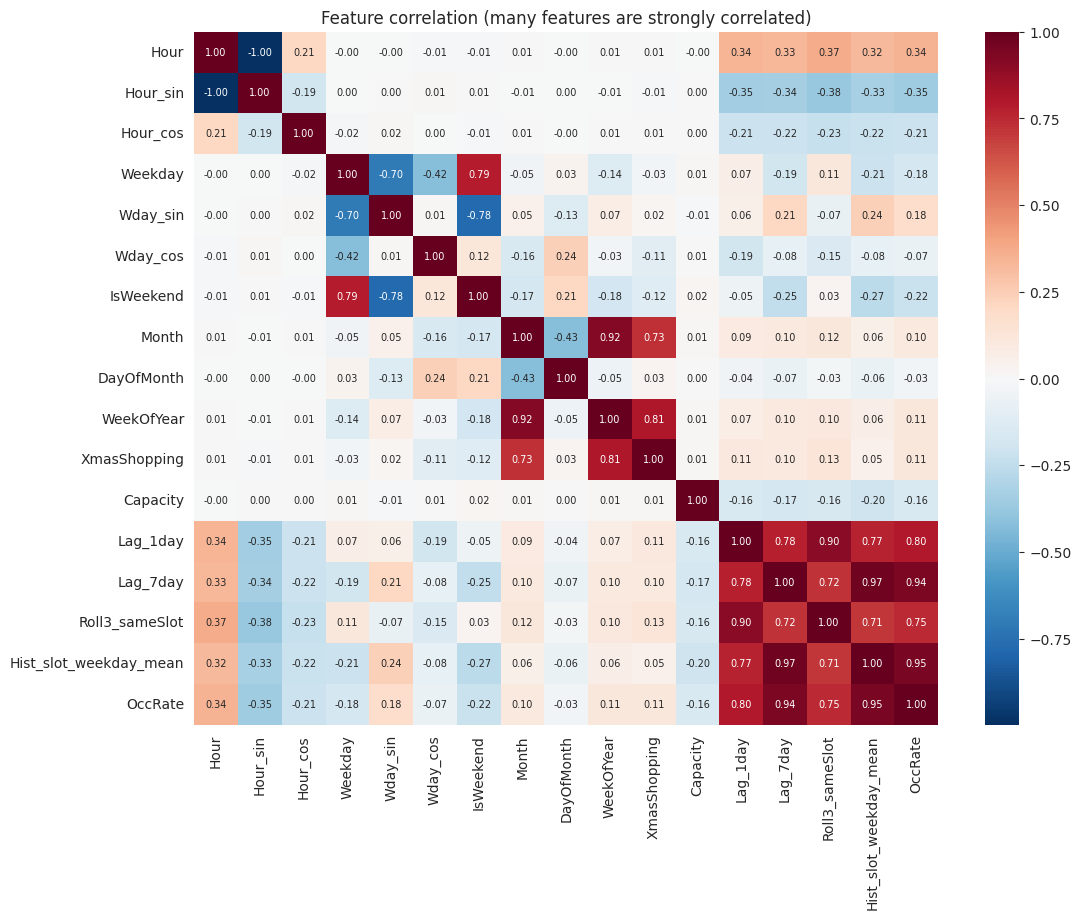

Train: 23707 rows (2016-10-11 -> 2016-12-05)
Test : 5610 rows (2016-12-06 -> 2016-12-19)
Best alpha    : 0.004924
Best l1_ratio : 0.9

Test-set performance (last 14 days, unseen):
                     MAE (rate)  RMSE (rate)      R2  MAE (vehicles)  RMSE (vehicles)
Linear Regression        0.0429       0.0631  0.9447         56.6808         108.6513
Lasso (L1)               0.0453       0.0657  0.9401         58.3284         112.5770
Ridge (L2)               0.0432       0.0631  0.9446         57.1860         108.6629
Elastic Net (L1+L2)      0.0452       0.0655  0.9405         58.0112         111.5946


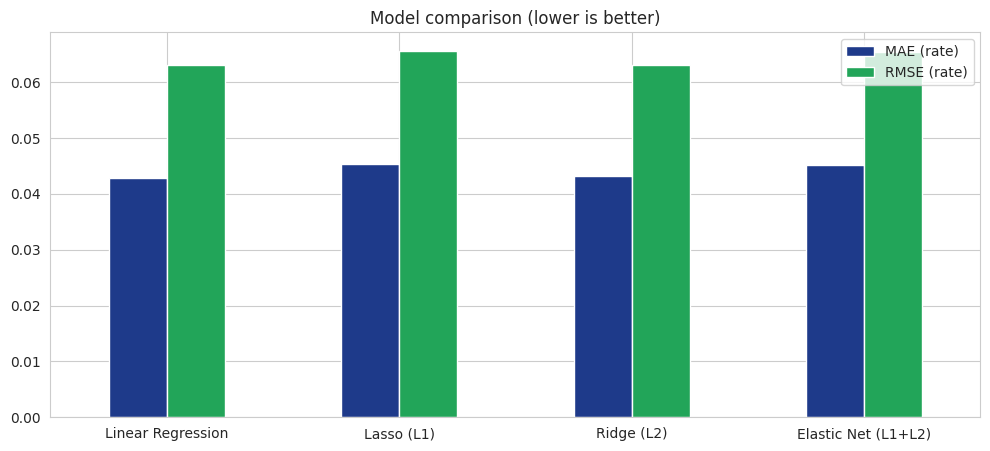

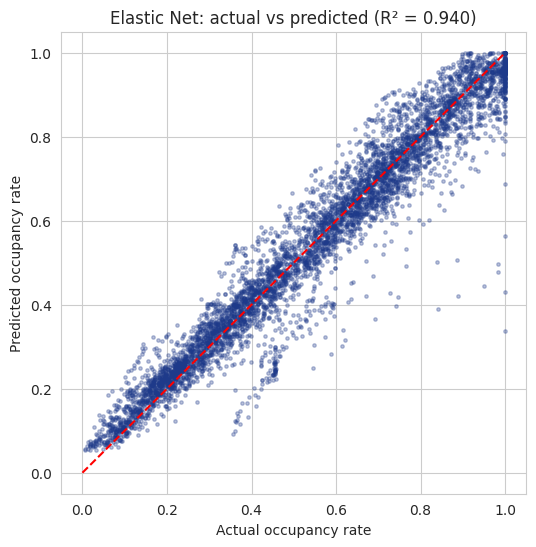

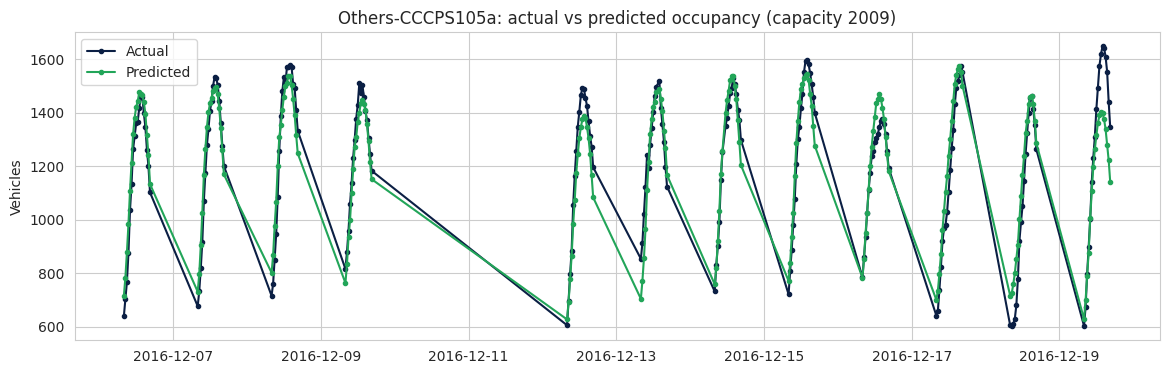

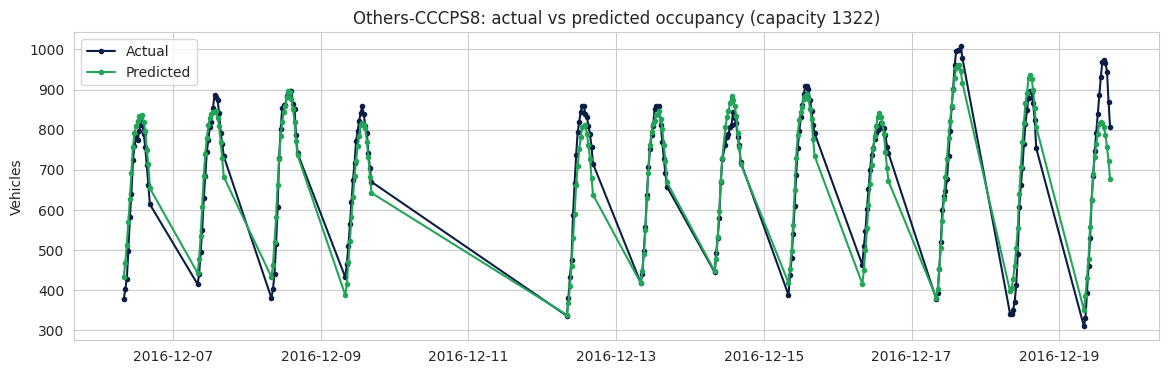

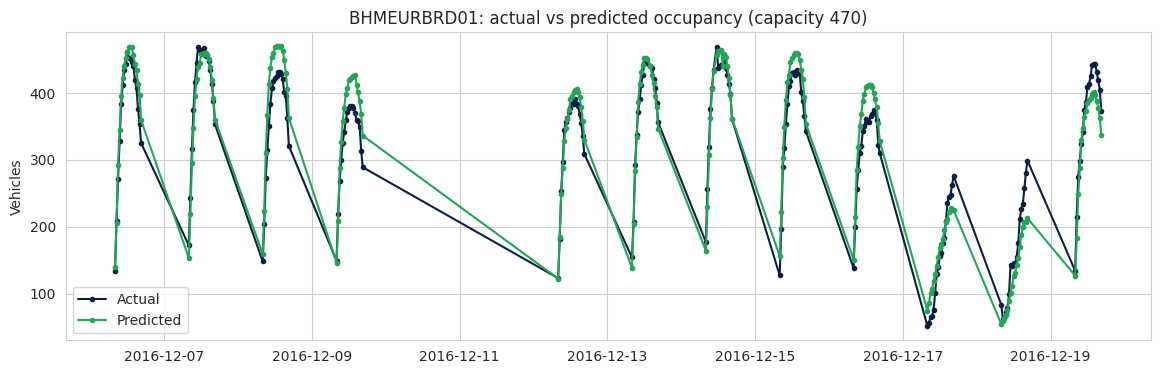

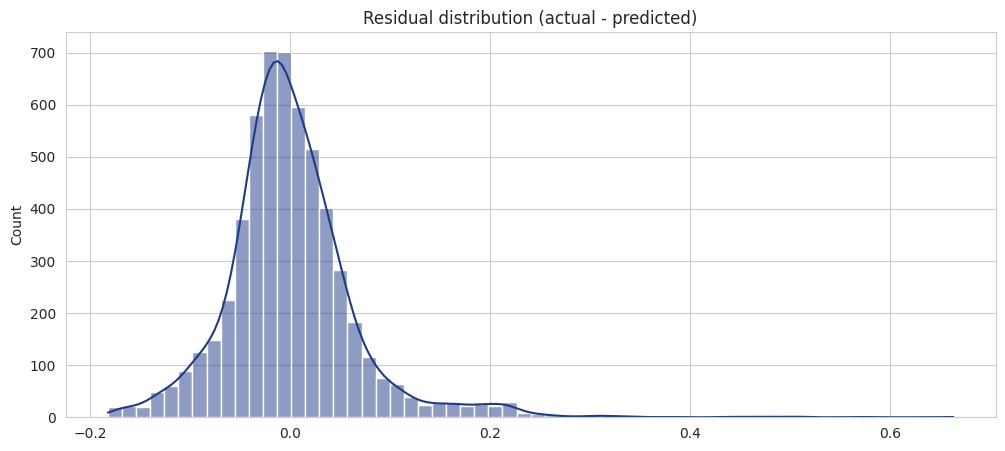

Features kept: 9 / 44  (Elastic Net shrank 35 coefficients to exactly zero)


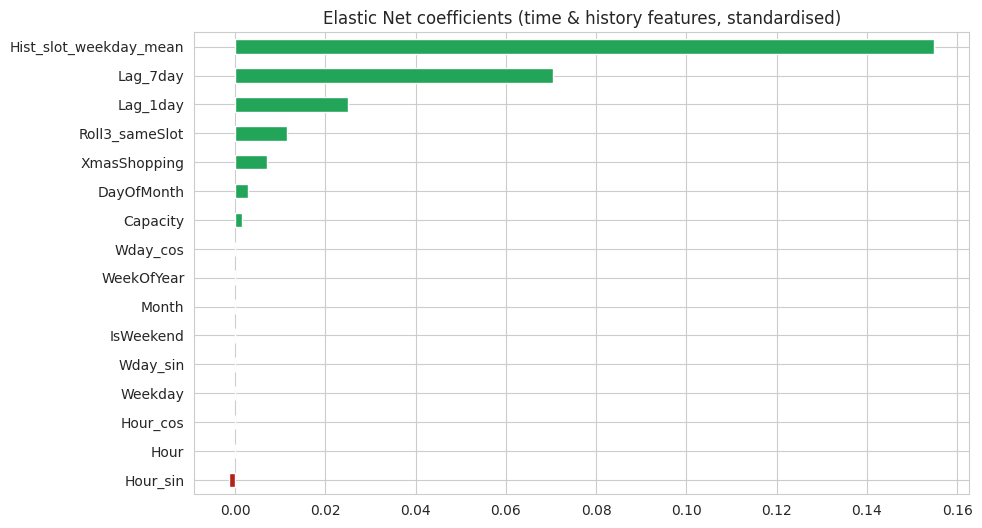

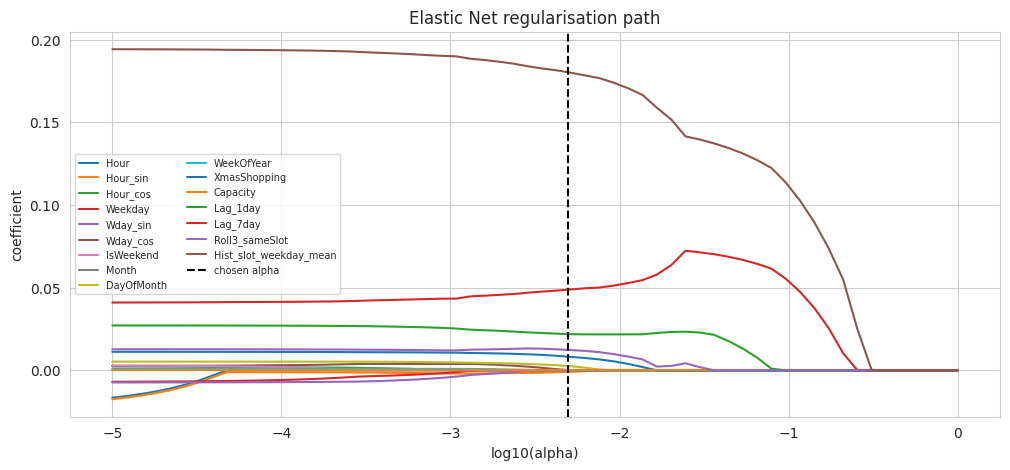


Forecast for Others-CCCPS105a on 2016-12-19:
 Time  Predicted rate %  Predicted vehicles  Actual vehicles    Status
08:00              31.3                 629              603 Available
08:30              34.8                 699              675 Available
09:00              39.4                 791              796 Available
09:30              43.6                 877              898 Available
10:00              50.0                1005             1001 Available
10:30              55.1                1106             1142 Available
11:00              59.5                1196             1231 Available
11:30              62.9                1263             1309 Available
12:00              65.4                1315             1413 Available
12:30              67.8                1361             1494 Available
13:00              69.2                1390             1575 Available
13:30              69.9                1404             1618 Available
14:00              69.6        

In [1]:
# =============================================================================
# PARKING DEMAND PREDICTION USING ELASTIC NET REGULARIZED REGRESSION
# Dataset : Birmingham parking occupancy (parking_birmingham.csv)
# Columns : SystemCodeNumber, Capacity, Occupancy, LastUpdated
# Run in Google Colab: paste each "# %%" block into its own cell (or all in one).
# =============================================================================

# %% STEP 0 - Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, LinearRegression, LassoCV, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (12, 5)
RANDOM_STATE = 42

# %% STEP 1 - Data collection (load the CSV)
CSV_NAME = "parking_birmingham.csv"

if not os.path.exists(CSV_NAME):
    try:
        from google.colab import files          # works only inside Colab
        print("Upload your parking CSV file ...")
        uploaded = files.upload()
        CSV_NAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"Put {CSV_NAME} next to this script.")

df = pd.read_csv(CSV_NAME)
print("Raw shape:", df.shape)
print(df.head())

# %% STEP 2 - Preprocessing / cleaning
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

before = len(df)
df = df.drop_duplicates(subset=["SystemCodeNumber", "LastUpdated"])  # duplicate readings
df = df.dropna()                                                       # missing values
df = df[(df["Occupancy"] >= 0) & (df["Capacity"] > 0)]                 # invalid readings
print(f"Removed {before - len(df)} duplicate / invalid rows")

# Target = occupancy rate (0..1) so car parks of different sizes are comparable.
df["OccRate"] = df["Occupancy"] / df["Capacity"]
# Outliers: a few sensors report more cars than spaces -> cap the rate at 1.0
print("Readings above capacity (capped):", (df["OccRate"] > 1).sum())
df["OccRate"] = df["OccRate"].clip(0, 1)

# Readings arrive at irregular times (07:59:42, 08:25:42 ...). Snap each one to its
# nearest 30-minute slot so the same slot can be compared across days.
df["Slot"] = df["LastUpdated"].dt.round("30min")
df = (df.groupby(["SystemCodeNumber", "Slot"], as_index=False)
        .agg(Capacity=("Capacity", "max"), Occupancy=("Occupancy", "mean"),
             OccRate=("OccRate", "mean")))
print("Clean shape:", df.shape, "| car parks:", df["SystemCodeNumber"].nunique())
print("Date range:", df["Slot"].min(), "->", df["Slot"].max())

# %% STEP 3 - Exploratory look at the demand patterns
df["Hour"] = df["Slot"].dt.hour + df["Slot"].dt.minute / 60
df["Weekday"] = df["Slot"].dt.dayofweek

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("Hour")["OccRate"].mean().plot(ax=ax[0], marker="o", color="#1E3A8A")
ax[0].set_title("Average occupancy rate by time of day"); ax[0].set_ylabel("Occupancy rate")
df.groupby("Weekday")["OccRate"].mean().plot(kind="bar", ax=ax[1], color="#22A559")
ax[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
ax[1].set_title("Average occupancy rate by weekday")
plt.tight_layout(); plt.show()

top = df.groupby("SystemCodeNumber")["OccRate"].mean().sort_values(ascending=False)
top.plot(kind="barh", figsize=(10, 8), color="#0B1F44", title="Average occupancy rate per car park")
plt.gca().invert_yaxis(); plt.show()

# %% STEP 4 - Feature engineering
df = df.sort_values(["SystemCodeNumber", "Slot"]).reset_index(drop=True)
df["Date"] = df["Slot"].dt.normalize()
df["TimeOfDay"] = df["Slot"].dt.strftime("%H:%M")

# --- Calendar / time features
df["IsWeekend"] = (df["Weekday"] >= 5).astype(int)
df["Month"] = df["Slot"].dt.month
df["DayOfMonth"] = df["Slot"].dt.day
df["WeekOfYear"] = df["Slot"].dt.isocalendar().week.astype(int)
# cyclic encoding so 23:00 and 00:00 are "close"
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)
df["Wday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
df["Wday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)
# Season / events proxy: run-up to Christmas shopping (Birmingham city centre)
df["XmasShopping"] = (df["Slot"] >= "2016-11-24").astype(int)   # Black Friday onwards

# --- Lag features (history known BEFORE the day we forecast -> day-ahead forecast)
key = ["SystemCodeNumber", "TimeOfDay"]

def add_lag(frame, days, name):
    lag = frame[key + ["Date", "OccRate"]].copy()
    lag["Date"] = lag["Date"] + pd.Timedelta(days=days)
    lag = lag.rename(columns={"OccRate": name})
    return frame.merge(lag, on=key + ["Date"], how="left")

df = add_lag(df, 1, "Lag_1day")      # same car park, same slot, yesterday
df = add_lag(df, 7, "Lag_7day")      # same car park, same slot, last week

# average of the same slot over the previous 3 days
for d in (2, 3):
    df = add_lag(df, d, f"_lag{d}")
df["Roll3_sameSlot"] = df[["Lag_1day", "_lag2", "_lag3"]].mean(axis=1)
df = df.drop(columns=["_lag2", "_lag3"])

# typical rate of this car park at this slot on this weekday (from earlier weeks only)
df = df.sort_values(["SystemCodeNumber", "Weekday", "TimeOfDay", "Date"])
df["Hist_slot_weekday_mean"] = (df.groupby(["SystemCodeNumber", "Weekday", "TimeOfDay"])["OccRate"]
                                  .transform(lambda s: s.shift(1).expanding().mean()))
df = df.sort_values(["SystemCodeNumber", "Slot"]).reset_index(drop=True)

# Missing lags: the first week has no "last week" history -> drop it.
# Small gaps later (a missed reading) are filled from the other history features.
lag_cols = ["Lag_1day", "Lag_7day", "Roll3_sameSlot", "Hist_slot_weekday_mean"]
df = df[df["Date"] >= df["Date"].min() + pd.Timedelta(days=7)]
df["Lag_1day"] = df["Lag_1day"].fillna(df["Roll3_sameSlot"]).fillna(df["Lag_7day"])
df["Roll3_sameSlot"] = df["Roll3_sameSlot"].fillna(df["Lag_7day"])
df["Hist_slot_weekday_mean"] = df["Hist_slot_weekday_mean"].fillna(df["Lag_7day"])
before = len(df)
df = df.dropna(subset=lag_cols)
print(f"Dropped {before - len(df)} rows with no usable history")

NUM_FEATURES = ["Hour", "Hour_sin", "Hour_cos", "Weekday", "Wday_sin", "Wday_cos", "IsWeekend",
                "Month", "DayOfMonth", "WeekOfYear", "XmasShopping", "Capacity"] + lag_cols
CAT_FEATURES = ["SystemCodeNumber"]       # location (one-hot encoded)
TARGET = "OccRate"
print("Features used:", len(NUM_FEATURES) + len(CAT_FEATURES))
print(df[NUM_FEATURES + [TARGET]].describe().T.round(3))

# correlation between features -> why we need Elastic Net (L2 handles correlated inputs)
plt.figure(figsize=(12, 9))
sns.heatmap(df[NUM_FEATURES + [TARGET]].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7})
plt.title("Feature correlation (many features are strongly correlated)"); plt.show()

# %% STEP 5 - Time-based train / test split (no shuffling: we predict the future)
df = df.sort_values("Slot").reset_index(drop=True)
split_date = df["Date"].max() - pd.Timedelta(days=14)          # last 2 weeks = test
train = df[df["Date"] <= split_date]
test = df[df["Date"] > split_date]
X_train, y_train = train[NUM_FEATURES + CAT_FEATURES], train[TARGET]
X_test, y_test = test[NUM_FEATURES + CAT_FEATURES], test[TARGET]
print(f"Train: {len(train)} rows ({train['Date'].min().date()} -> {train['Date'].max().date()})")
print(f"Test : {len(test)} rows ({test['Date'].min().date()} -> {test['Date'].max().date()})")

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),                              # normalisation
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

# %% STEP 6 - Elastic Net model (L1 + L2), tuned by time-series cross-validation
#   Loss = (1/2n)*||y - Xw||^2 + alpha * [ l1_ratio*||w||_1 + 0.5*(1-l1_ratio)*||w||_2^2 ]
#   l1_ratio = 1 -> Lasso,  l1_ratio = 0 -> Ridge
tscv = TimeSeriesSplit(n_splits=5)
enet = Pipeline([
    ("prep", preprocess),
    ("model", ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                           alphas=np.logspace(-5, 0, 40),
                           cv=tscv, max_iter=20000, n_jobs=-1, random_state=RANDOM_STATE)),
])
enet.fit(X_train, y_train)
best = enet.named_steps["model"]
print(f"Best alpha    : {best.alpha_:.6f}")
print(f"Best l1_ratio : {best.l1_ratio_}")

# %% STEP 7 - Baselines for comparison
models = {
    "Linear Regression": Pipeline([("prep", preprocess), ("model", LinearRegression())]),
    "Lasso (L1)": Pipeline([("prep", preprocess),
                            ("model", LassoCV(alphas=np.logspace(-5, 0, 40), cv=tscv, max_iter=20000))]),
    "Ridge (L2)": Pipeline([("prep", preprocess), ("model", RidgeCV(alphas=np.logspace(-3, 3, 40)))]),
}
for m in models.values():
    m.fit(X_train, y_train)
models["Elastic Net (L1+L2)"] = enet

# %% STEP 8 - Evaluation: MAE, RMSE, R^2
def evaluate(model, X, y, cap):
    pred = np.clip(model.predict(X), 0, 1)
    return {
        "MAE (rate)": mean_absolute_error(y, pred),
        "RMSE (rate)": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "MAE (vehicles)": mean_absolute_error(y * cap, pred * cap),
        "RMSE (vehicles)": np.sqrt(mean_squared_error(y * cap, pred * cap)),
    }

results = pd.DataFrame({name: evaluate(m, X_test, y_test, test["Capacity"])
                        for name, m in models.items()}).T
print("\nTest-set performance (last 14 days, unseen):")
print(results.round(4))

results[["MAE (rate)", "RMSE (rate)"]].plot(kind="bar", color=["#1E3A8A", "#22A559"],
                                            title="Model comparison (lower is better)")
plt.xticks(rotation=0); plt.show()

# %% STEP 9 - Visualise the Elastic Net forecast
test = test.copy()
test["Pred"] = np.clip(enet.predict(X_test), 0, 1)

# (a) predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(test[TARGET], test["Pred"], s=6, alpha=0.3, color="#1E3A8A")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual occupancy rate"); plt.ylabel("Predicted occupancy rate")
plt.title(f"Elastic Net: actual vs predicted (R² = {results.loc['Elastic Net (L1+L2)', 'R2']:.3f})")
plt.show()

# (b) time series for a few car parks
for cp in test["SystemCodeNumber"].value_counts().index[:3]:
    s = test[test["SystemCodeNumber"] == cp]
    plt.figure(figsize=(14, 4))
    plt.plot(s["Slot"], s["Occupancy"], ".-", label="Actual", color="#0B1F44")
    plt.plot(s["Slot"], s["Pred"] * s["Capacity"], ".-", label="Predicted", color="#22A559")
    plt.title(f"{cp}: actual vs predicted occupancy (capacity {s['Capacity'].iloc[0]})")
    plt.ylabel("Vehicles"); plt.legend(); plt.show()

# (c) residuals
res = test[TARGET] - test["Pred"]
sns.histplot(res, bins=60, kde=True, color="#1E3A8A")
plt.title("Residual distribution (actual - predicted)"); plt.show()

# %% STEP 10 - Which features matter? (Elastic Net coefficients)
feat_names = NUM_FEATURES + list(
    enet.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(CAT_FEATURES))
coef = pd.Series(best.coef_, index=feat_names)
print(f"Features kept: {(coef != 0).sum()} / {len(coef)}  "
      f"(Elastic Net shrank {(coef == 0).sum()} coefficients to exactly zero)")
coef_num = coef[NUM_FEATURES].sort_values()
coef_num.plot(kind="barh", figsize=(10, 6),
              color=["#B42318" if v < 0 else "#22A559" for v in coef_num])
plt.title("Elastic Net coefficients (time & history features, standardised)"); plt.show()

# regularisation path: how coefficients shrink as alpha grows (fixed best l1_ratio)
from sklearn.linear_model import enet_path
Xt = enet.named_steps["prep"].transform(X_train)
alphas_p, coefs_p, _ = enet_path(Xt, y_train.values, l1_ratio=best.l1_ratio_,
                                 alphas=np.logspace(-5, 0, 60))
plt.figure(figsize=(12, 5))
for i, name in enumerate(feat_names):
    if name in NUM_FEATURES:
        plt.plot(np.log10(alphas_p), coefs_p[i], label=name)
plt.axvline(np.log10(best.alpha_), ls="--", color="k", label="chosen alpha")
plt.xlabel("log10(alpha)"); plt.ylabel("coefficient")
plt.title("Elastic Net regularisation path"); plt.legend(fontsize=7, ncol=2); plt.show()

# %% STEP 11 - Use the model: forecast a car park for a chosen day
def forecast_day(car_park, date):
    """Day-ahead forecast for one car park, using only history before `date`."""
    date = pd.Timestamp(date).normalize()
    rows = df[(df["SystemCodeNumber"] == car_park) & (df["Date"] == date)]
    if rows.empty:
        raise ValueError("No slots for that car park / date in the data")
    pred = np.clip(enet.predict(rows[NUM_FEATURES + CAT_FEATURES]), 0, 1)
    out = pd.DataFrame({"Time": rows["TimeOfDay"].values,
                        "Predicted rate %": (pred * 100).round(1),
                        "Predicted vehicles": (pred * rows["Capacity"].values).round(0).astype(int),
                        "Actual vehicles": rows["Occupancy"].round(0).astype(int).values})
    out["Status"] = np.where(pred >= 0.9, "LIKELY FULL", np.where(pred >= 0.7, "Busy", "Available"))
    return out

example_cp = test["SystemCodeNumber"].iloc[0]
example_day = test["Date"].max()
print(f"\nForecast for {example_cp} on {example_day.date()}:")
print(forecast_day(example_cp, example_day).to_string(index=False))

print("\nDone. Elastic Net summary:")
print(results.loc["Elastic Net (L1+L2)"].round(4))